In [1]:
from my_implementation.utils.paths import get_results_root, list_available_runs
from my_implementation.analysis.plotting import plot_training_comparison
from my_implementation.analysis.summary import summary_table
from my_implementation.utils.paths import get_results_root, get_videos_dir
from my_implementation.analysis.render import render_run_video

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


MyoSuite:> Registering Myo Envs


In [2]:
results_root = get_results_root()
eval_logs_dir = results_root / "eval_logs"
checkpoints_dir = results_root / "checkpoints"

run_names = list_available_runs(eval_logs_dir)
print(f"Runs disponibles : {run_names}")


Runs disponibles : ['test']


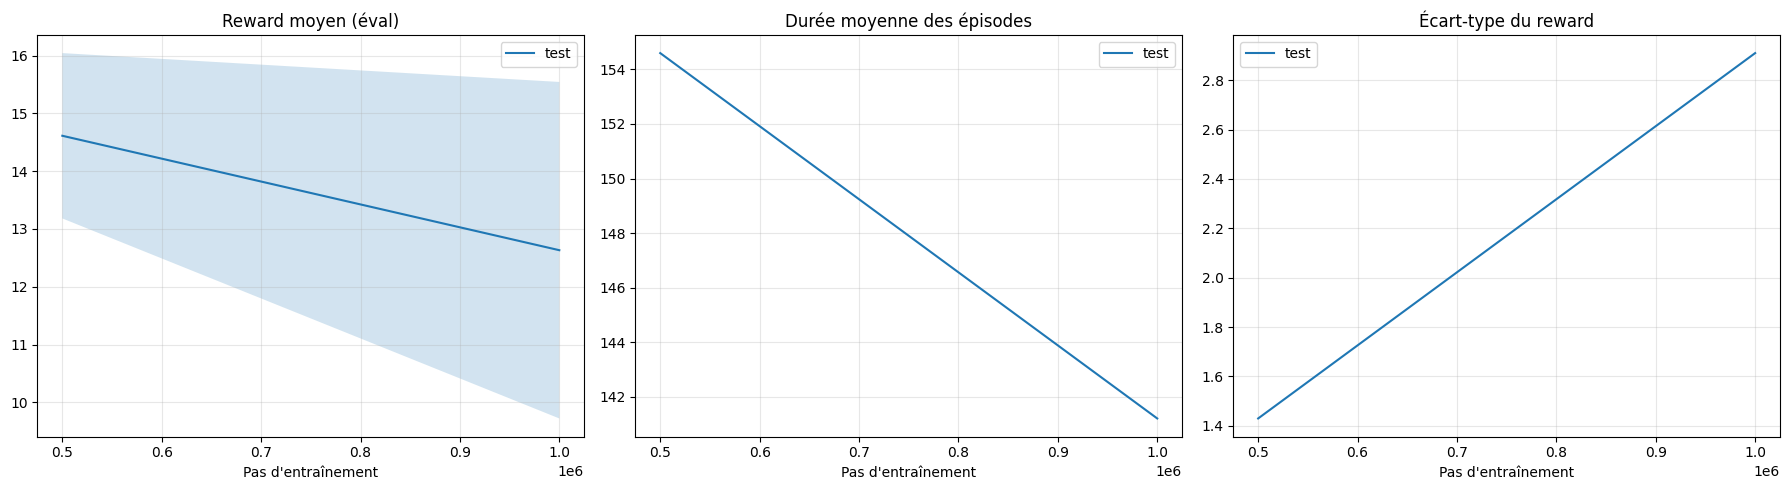

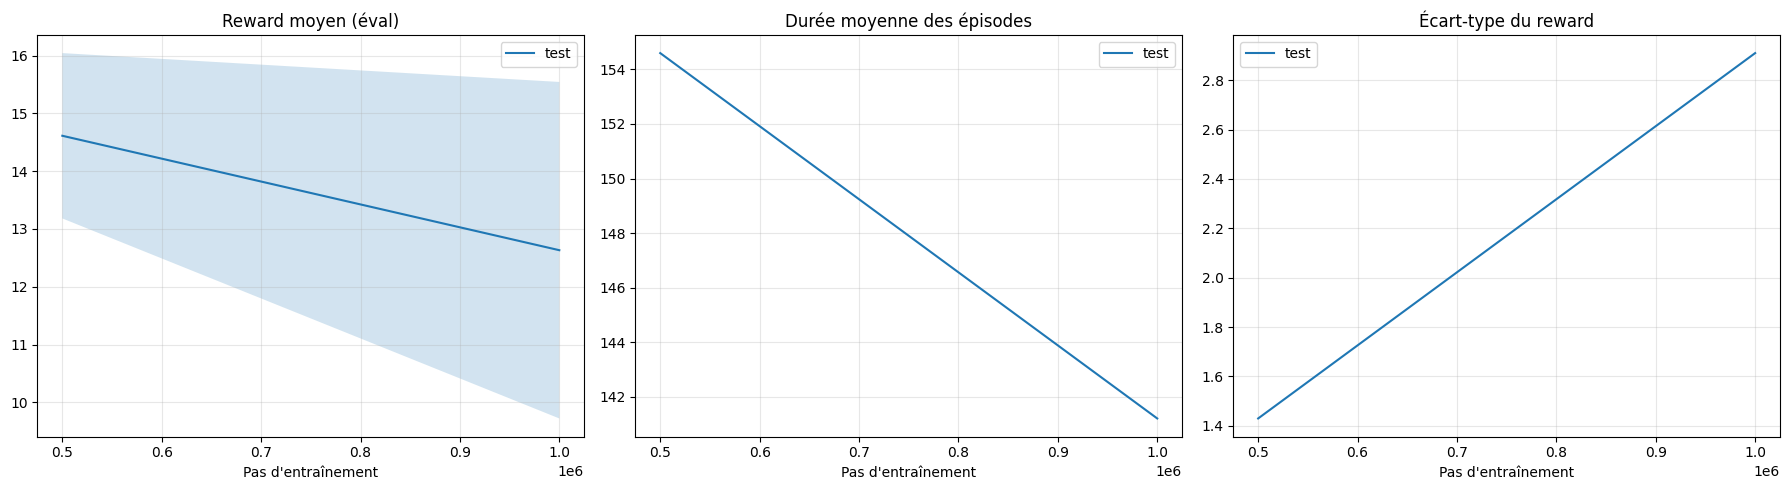

In [3]:
plot_training_comparison(run_names, eval_logs_dir, results_root / "training_comparison.png")


In [4]:
summary_table(run_names, checkpoints_dir, results_root / "summary.csv")

Évaluation de test (checkpoint: test_1000000_steps.zip)...
    MyoSuite: A contact-rich simulation suite for musculoskeletal motor control
        Vittorio Caggiano, Huawei Wang, Guillaume Durandau, Massimo Sartori, Vikash Kumar
        L4DC-2019 | https://sites.google.com/view/myosuite
    


c:\Users\ST000082\Documents\Codes\myosuite-soph\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\ST000082\Documents\Codes\myosuite-soph\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
c:\Users\ST000082\Documents\Codes\myosuite-soph\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\ST000082\Documents\Codes\myosuite-soph\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


[RunTrackImitation] Vitesse cible recalculée depuis la référence : 1.2421 m/s
          distance_mean  distance_std  ep_len_mean  ep_len_std  fall_rate  \
run_name                                                                    
test          14.825967      0.391942       157.35   34.223201       0.95   

                      checkpoint  
run_name                          
test      test_1000000_steps.zip  


,distance_mean,distance_std,ep_len_mean,ep_len_std,fall_rate,checkpoint
run_name,,,,,,
test,14.825967,0.391942,157.35,34.223201,0.95,test_1000000_steps.zip


In [7]:
results_root = get_results_root()
run_name = "test"
weighted_reward_keys = {"sparse": 1, "solved": 10, "qpos_imitation": 40}

best_model_path = results_root / "checkpoints" / run_name / "best_model"
final_model_path = results_root / "checkpoints" / f"{run_name}_final"
model_path = best_model_path if best_model_path.exists() else final_model_path
print(f"Chargement du modèle depuis : {model_path}")

render_run_video(
    weighted_reward_keys=weighted_reward_keys,
    model_path=str(model_path),
    savepath=str(get_videos_dir() / f"{run_name}.mp4"),
)

Chargement du modèle depuis : C:\Users\ST000082\OneDrive - Vrije Universiteit Brussel\05-PredictiveSimulations\01-MyoSuite\results\checkpoints\test_final
[RunTrackImitation] Vitesse cible recalculée depuis la référence : 1.2421 m/s
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\ST000082\Documents\Codes\myosuite-soph\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\ST000082\Documents\Codes\myosuite-soph\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
 20%|██        | 1/5 [00:28<01:54, 28.64s/it]

Episode 0: reward=-29.84, steps=181


 40%|████      | 2/5 [00:57<01:25, 28.57s/it]

Episode 1: reward=118.14, steps=167


...

Episode 3: reward=97.72, steps=107


100%|██████████| 5/5 [01:59<00:00, 23.86s/it]

Episode 4: reward=110.96, steps=142


Average reward: 79.10 over 5 épisodes


[-29.84051459971668,
 118.14203737476075,
 98.5379329376574,
 97.71514068158383,
 110.95704684482706]